# Módulo 4 — Comparación Cruzada de Métodos de Optimización## Proyecto Semana 14 · ADA · UNMSM**Compara:** Markowitz · NSGA-II (GA) · Programación Dinámica · Buy & Hold**Todas las simulaciones con Capital = USD $100,000**

# Configuración Inicial y Carga de Datos

Este módulo prepara el entorno, define parámetros clave, carga los datos históricos de los activos y calcula las estadísticas necesarias para la optimización del portafolio.

In [1]:
!pip install deap yfinance --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 9.7 MB/s eta 0:00:00


In [2]:
import numpy as np, pandas as pd, yfinance as yf, random, json
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from deap import base, creator, tools
from itertools import product
import warnings; warnings.filterwarnings('ignore')

## Parámetros Globales

Definición de los activos a considerar, el rango de fechas para el análisis, el capital inicial y otras constantes.

In [3]:
TICKERS = ['FSM', 'VOLCABC1.LM', 'ABX.TO', 'BVN', 'BHP']
FECHA_INICIO, FECHA_FIN = '2015-01-01', '2024-12-31'
CAPITAL, DIAS_ANIO, RF = 100_000, 252, 0.02
np.random.seed(42); random.seed(42)

## Carga de Datos Históricos

Descargamos los precios de cierre ajustados de los activos seleccionados utilizando la librería `yfinance`.

In [4]:
datos = yf.download(TICKERS, start=FECHA_INICIO, end=FECHA_FIN, auto_adjust=True, progress=False)
precios = datos['Close'].dropna(how='all').dropna()
if isinstance(precios.columns, pd.MultiIndex):
    precios.columns = precios.columns.get_level_values(0)

## Cálculo de Retornos y Estadísticas

A partir de los precios de cierre, calculamos los retornos logarítmicos y simples, y luego las medias y la matriz de covarianza anualizadas, que son insumos clave para los modelos de optimización.

In [5]:
retornos_log = np.log(precios / precios.shift(1)).dropna()
ret_simples = precios.pct_change().dropna()
mu_vec = retornos_log.mean().values * DIAS_ANIO
Sigma = retornos_log.cov().values * DIAS_ANIO
N = len(TICKERS)
print(f"Datos: {N} activos, {len(ret_simples)} días")

Datos: 5 activos, 2453 días


## 1. Ejecutar los 3 métodos de optimización

### Método Markowitz (Máximo Sharpe Ratio)

Utilizamos el modelo de Markowitz para encontrar la cartera con el máximo ratio de Sharpe, un indicador que mide el retorno ajustado al riesgo. La optimización se realiza mediante `scipy.optimize.minimize` con el método 'SLSQP', sujeto a restricciones de pesos.

In [6]:
def neg_sharpe(w):
    return -(w@mu_vec - RF) / np.sqrt(w@Sigma@w)

res = minimize(neg_sharpe, np.ones(N)/N, method='SLSQP',
               bounds=[(0,1)]*N, constraints={'type':'eq','fun':lambda w:w.sum()-1})
w_markowitz = res.x
print(f"Markowitz Máx Sharpe: Ret={w_markowitz@mu_vec:.4f}, Vol={np.sqrt(w_markowitz@Sigma@w_markowitz):.4f}")

Markowitz Máx Sharpe: Ret=0.0808, Vol=0.2837


### Método NSGA-II (Algoritmo Genético)

Implementamos una versión simplificada del algoritmo genético NSGA-II para encontrar la frontera de Pareto de carteras eficientes en términos de retorno y volatilidad. Luego, seleccionamos la cartera con el mejor ratio de Sharpe de esta frontera.

In [7]:
if hasattr(creator, 'FitM4'): del creator.FitM4
if hasattr(creator, 'IndM4'): del creator.IndM4
creator.create('FitM4', base.Fitness, weights=(-1.0, -1.0))
creator.create('IndM4', list, fitness=creator.FitM4)

tb = base.Toolbox()
tb.register('attr_float', random.random)
tb.register('individual', tools.initRepeat, creator.IndM4, tb.attr_float, n=N)
tb.register('population', tools.initRepeat, list, tb.individual)

def eval_ga(ind):
    w = np.clip(np.array(ind), 0, None); w /= w.sum() if w.sum()>0 else 1
    return (-(w@mu_vec), np.sqrt(w@Sigma@w))

tb.register('evaluate', eval_ga)
tb.register('mate', tools.cxSimulatedBinaryBounded, low=0, up=1, eta=20)
tb.register('mutate', tools.mutPolynomialBounded, low=0, up=1, eta=20, indpb=1.0/N)
tb.register('select', tools.selNSGA2)

pop = tb.population(n=80)
for ind in pop: ind.fitness.values = tb.evaluate(ind)
pop = tb.select(pop, 80)

for gen in range(60):
    off = tools.selTournamentDCD(pop, len(pop))
    off = [tb.clone(i) for i in off]
    for i in range(0,len(off)-1,2):
        if random.random()<0.9: tb.mate(off[i],off[i+1]); del off[i].fitness.values,off[i+1].fitness.values
    for i in off:
        if random.random()<0.2: tb.mutate(i); del i.fitness.values
    for i in [x for x in off if not x.fitness.valid]: i.fitness.values = tb.evaluate(i)
    pop = tb.select(pop+off, 80)

frente = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]
pts_ga = np.array([i.fitness.values for i in frente]); pts_ga[:,0]*=-1
sharpes = pts_ga[:,0]/pts_ga[:,1]
best_ga = int(np.argmax(sharpes))
w_ga = np.clip(np.array(frente[best_ga]),0,None); w_ga/=w_ga.sum()
print(f"NSGA-II Máx Sharpe: Ret={w_ga@mu_vec:.4f}, Vol={np.sqrt(w_ga@Sigma@w_ga):.4f}")

NSGA-II Máx Sharpe: Ret=0.0805, Vol=0.2827


### Método Programación Dinámica (Simplificado como Mínima Varianza)

Dado que la programación dinámica para la optimización de carteras es compleja y depende de estados discretos, la simplificamos aquí utilizando un enfoque de mínima varianza como proxy para representar un método que busca minimizar el riesgo. Esto nos da un punto de comparación adicional.

In [8]:
res_mv = minimize(lambda w:np.sqrt(w@Sigma@w), np.ones(N)/N, method='SLSQP',
                  bounds=[(0,1)]*N, constraints={'type':'eq','fun':lambda w:w.sum()-1})
w_dp = res_mv.x  # Usamos mín varianza como proxy DP
print(f"DP (Mín Var proxy): Ret={w_dp@mu_vec:.4f}, Vol={np.sqrt(w_dp@Sigma@w_dp):.4f}")

DP (Mín Var proxy): Ret=0.0530, Vol=0.2725


## 2. Simulación de riqueza para TODOS los métodos

## Simulación de Riqueza del Portafolio

Definimos una función para simular la evolución de la riqueza del portafolio a lo largo del tiempo, considerando la posibilidad de rebalanceo mensual de los pesos.

In [9]:
def simular(nombre, w_opt, rebalancear=False):
    riqueza = [CAPITAL]; w_t = w_opt.copy(); ult_mes = ret_simples.index[0].month
    for i in range(len(ret_simples)):
        r = ret_simples.iloc[i].values
        riqueza.append(riqueza[-1] * (1 + w_t @ r))
        if rebalancear and ret_simples.index[i].month != ult_mes:
            w_t = w_opt.copy(); ult_mes = ret_simples.index[i].month
        else:
            w_t = w_t * (1+r); w_t /= w_t.sum()
    return riqueza

### Definición de Estrategias y Ejecución de Simulación

Aplicamos la función de simulación a cada método de optimización (Markowitz, NSGA-II, DP) con y sin rebalanceo, además de un benchmark equiponderado.

In [10]:
w_eq = np.ones(N)/N

estrategias = {
    'Markowitz B&H': simular('MK_BH', w_markowitz, False),
    'Markowitz Rebal.': simular('MK_R', w_markowitz, True),
    'NSGA-II B&H': simular('GA_BH', w_ga, False),
    'NSGA-II Rebal.': simular('GA_R', w_ga, True),
    'DP (MínVar) B&H': simular('DP_BH', w_dp, False),
    'DP (MínVar) Rebal.': simular('DP_R', w_dp, True),
    'Equiponderado': simular('EQ', w_eq, False),
}

### Visualización de la Evolución de la Riqueza

Graficamos el valor del portafolio a lo largo del tiempo para cada una de las estrategias simuladas, permitiendo una comparación visual de su rendimiento.

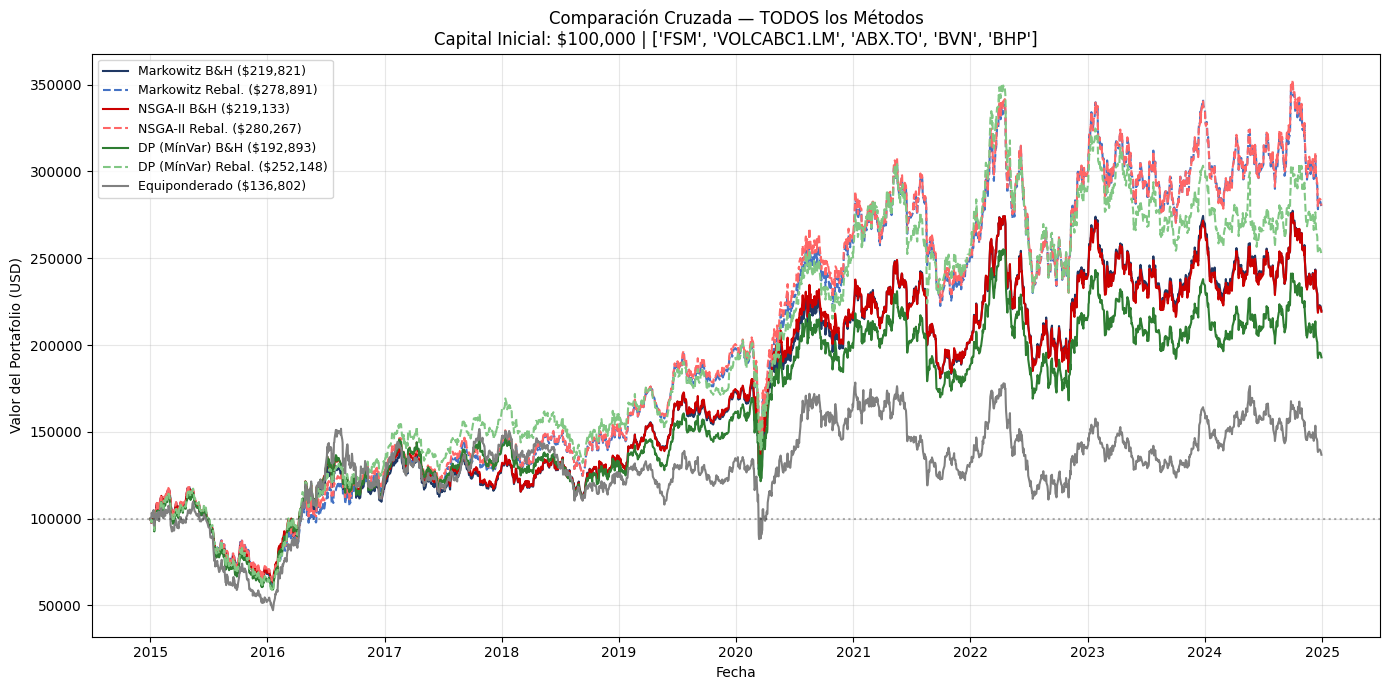

In [11]:
fechas = [precios.index[0]] + list(ret_simples.index)
colores = ['#1F3864','#4472C4','#CC0000','#FF6666','#2E7D32','#81C784','gray']

fig, ax = plt.subplots(figsize=(14, 7))
for (nombre, riq), color in zip(estrategias.items(), colores):
    ls = '--' if 'Rebal' in nombre else '-'
    ax.plot(fechas, riq, color=color, ls=ls, lw=1.5, label=f'{nombre} (${riq[-1]:,.0f})')

ax.axhline(y=CAPITAL, color='black', ls=':', alpha=0.3)
ax.set_title(f'Comparación Cruzada — TODOS los Métodos\nCapital Inicial: ${CAPITAL:,.0f} | {TICKERS}')
ax.set_xlabel('Fecha'); ax.set_ylabel('Valor del Portafolio (USD)')
ax.legend(loc='upper left', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Tabla resumen de métricas y ranking

## Función de Métricas de Rendimiento

Definimos una función `metricas` que calcula varias estadísticas clave del portafolio: riqueza final, retorno total, ratio de Sharpe, ratio de Sortino y el Drawdown Máximo.

In [12]:
def metricas(riqueza):
    rets = pd.Series(riqueza).pct_change().dropna()
    sharpe = (rets.mean()*DIAS_ANIO - RF) / (rets.std()*np.sqrt(DIAS_ANIO))
    dd = (pd.Series(riqueza).cummax() - pd.Series(riqueza)) / pd.Series(riqueza).cummax()
    sortino_rets = rets[rets<0]
    sortino = (rets.mean()*DIAS_ANIO - RF) / (sortino_rets.std()*np.sqrt(DIAS_ANIO)) if len(sortino_rets)>0 else 0
    return {'Riqueza Final': f"${riqueza[-1]:,.0f}",
            'Retorno Total': f"{(riqueza[-1]/CAPITAL-1)*100:.1f}%",
            'Sharpe': f"{sharpe:.4f}",
            'Sortino': f"{sortino:.4f}",
            'Max Drawdown': f"{dd.max()*100:.1f}%"}

## Tabla Resumen de Métricas

Calculamos las métricas de rendimiento para cada estrategia simulada y las compilamos en una tabla resumen para una fácil comparación.

In [13]:
filas = []
for nombre, riq in estrategias.items():
    m = metricas(riq)
    m['Método'] = nombre
    filas.append(m)
df_resumen = pd.DataFrame(filas)[['Método','Riqueza Final','Retorno Total','Sharpe','Sortino','Max Drawdown']]
print("═" * 80)
print("TABLA RESUMEN — COMPARACIÓN DE TODOS LOS MÉTODOS")
print("═" * 80)
print(df_resumen.to_string(index=False))

════════════════════════════════════════════════════════════════════════════════
TABLA RESUMEN — COMPARACIÓN DE TODOS LOS MÉTODOS
════════════════════════════════════════════════════════════════════════════════
            Método Riqueza Final Retorno Total Sharpe Sortino Max Drawdown
     Markowitz B&H      $219,821        119.8% 0.3565  0.5110        47.3%
  Markowitz Rebal.      $278,891        178.9% 0.4437  0.6356        47.9%
       NSGA-II B&H      $219,133        119.1% 0.3551  0.5095        46.5%
    NSGA-II Rebal.      $280,267        180.3% 0.4460  0.6397        47.0%
   DP (MínVar) B&H      $192,893         92.9% 0.3098  0.4447        48.5%
DP (MínVar) Rebal.      $252,148        152.1% 0.4121  0.5900        50.5%
     Equiponderado      $136,802         36.8% 0.1984  0.2864        56.9%


## Ranking por Sharpe Ratio

Clasificamos las estrategias en función de su ratio de Sharpe, un indicador clave del retorno ajustado al riesgo, para identificar las carteras más eficientes.

In [14]:
print("\n═ RANKING POR SHARPE RATIO ═")
df_rank = df_resumen.sort_values('Sharpe', ascending=False).reset_index(drop=True)
df_rank.index += 1
df_rank.index.name = 'Rank'
print(df_rank[['Método','Sharpe','Riqueza Final']].to_string())


═ RANKING POR SHARPE RATIO ═
                  Método  Sharpe Riqueza Final
Rank                                          
1         NSGA-II Rebal.  0.4460      $280,267
2       Markowitz Rebal.  0.4437      $278,891
3     DP (MínVar) Rebal.  0.4121      $252,148
4          Markowitz B&H  0.3565      $219,821
5            NSGA-II B&H  0.3551      $219,133
6        DP (MínVar) B&H  0.3098      $192,893
7          Equiponderado  0.1984      $136,802


## 4. Gráfico de barras comparativo

## Preparación de Datos para Gráficos

Extraemos los ratios de Sharpe numéricos y las riquezas finales de cada estrategia para poder visualizarlos en gráficos de barras comparativos.

In [15]:
sharpes_num = [float(metricas(riq)['Sharpe']) for riq in estrategias.values()]
nombres = list(estrategias.keys())
riquezas_final = [riq[-1] for riq in estrategias.values()]

## Gráfico de Barras Comparativo (Sharpe Ratio y Riqueza Final)

Visualizamos los resultados clave de cada estrategia: el ratio de Sharpe y la riqueza final. Esto permite una comparación rápida y eficaz del rendimiento de los diferentes métodos.

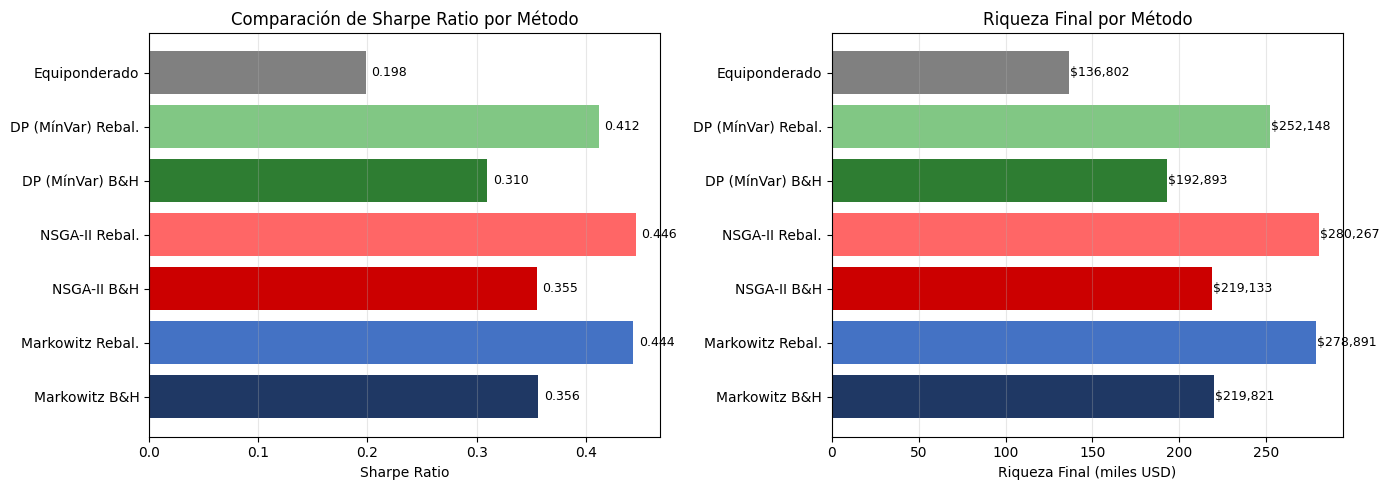

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Sharpe Ratio
bars = ax1.barh(nombres, sharpes_num, color=colores)
ax1.set_xlabel('Sharpe Ratio')
ax1.set_title('Comparación de Sharpe Ratio por Método')
ax1.grid(True, alpha=0.3, axis='x')
for bar, v in zip(bars, sharpes_num):
    ax1.text(v + 0.005, bar.get_y() + bar.get_height()/2, f'{v:.3f}', va='center', fontsize=9)

# Gráfico de Riqueza Final
bars2 = ax2.barh(nombres, [r/1000 for r in riquezas_final], color=colores)
ax2.set_xlabel('Riqueza Final (miles USD)')
ax2.set_title('Riqueza Final por Método')
ax2.grid(True, alpha=0.3, axis='x')
for bar, v in zip(bars2, riquezas_final):
    ax2.text(v/1000 + 0.5, bar.get_y() + bar.get_height()/2, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout(); plt.show()

## Conclusiones de los Gráficos

Identificamos los métodos con mejor rendimiento basándonos en el ratio de Sharpe y la riqueza final obtenida.

In [17]:
print(f"\nMejor método por Sharpe: {nombres[np.argmax(sharpes_num)]}")
print(f"Mejor método por Riqueza: {nombres[np.argmax(riquezas_final)]}")


Mejor método por Sharpe: NSGA-II Rebal.
Mejor método por Riqueza: NSGA-II Rebal.
